## Effect of social media on students

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("Students Social Media Addiction.csv")

In [5]:
df

,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
0,1,19,Female,Undergraduate,Bangladesh,5.2,Instagram,Yes,6.5,6,In Relationship,3,8
1,2,22,Male,Graduate,India,2.1,Twitter,No,7.5,8,Single,0,3
2,3,20,Female,Undergraduate,USA,6.0,TikTok,Yes,5.0,5,Complicated,4,9
3,4,18,Male,High School,UK,3.0,YouTube,No,7.0,7,Single,1,4
4,5,21,Male,Graduate,Canada,4.5,Facebook,Yes,6.0,6,In Relationship,2,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...
700,701,20,Female,Undergraduate,Italy,4.7,TikTok,No,7.2,7,In Relationship,2,5
701,702,23,Male,Graduate,Russia,6.8,Instagram,Yes,5.9,4,Single,5,9
702,703,21,Female,Undergraduate,China,5.6,WeChat,Yes,6.7,6,In Relationship,3,7
703,704,24,Male,Graduate,Japan,4.3,Twitter,No,7.5,8,Single,2,4


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 705 entries, 0 to 704
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Student_ID                    705 non-null    int64  
 1   Age                           705 non-null    int64  
 2   Gender                        705 non-null    object 
 3   Academic_Level                705 non-null    object 
 4   Country                       705 non-null    object 
 5   Avg_Daily_Usage_Hours         705 non-null    float64
 6   Most_Used_Platform            705 non-null    object 
 7   Affects_Academic_Performance  705 non-null    object 
 8   Sleep_Hours_Per_Night         705 non-null    float64
 9   Mental_Health_Score           705 non-null    int64  
 10  Relationship_Status           705 non-null    object 
 11  Conflicts_Over_Social_Media   705 non-null    int64  
 12  Addicted_Score                705 non-null    int64  
dtypes: fl

## Data that needs to be analyzed:

- How do social media platforms affect performance of students?
- Effect of social media on students' mental health.
- What country with the most social media addicted students?

## Goal 1: How do social media platforms affect performance of students?

In [10]:
performance = df[['Academic_Level', 'Avg_Daily_Usage_Hours' ,'Affects_Academic_Performance']]

In [11]:
performance

,Academic_Level,Avg_Daily_Usage_Hours,Affects_Academic_Performance
0,Undergraduate,5.2,Yes
1,Graduate,2.1,No
2,Undergraduate,6.0,Yes
3,High School,3.0,No
4,Graduate,4.5,Yes
...,...,...,...
700,Undergraduate,4.7,No
701,Graduate,6.8,Yes
702,Undergraduate,5.6,Yes
703,Graduate,4.3,No


In [12]:
performance_hours = performance.sort_values(by = 'Avg_Daily_Usage_Hours', ascending = False)

In [13]:
performance_hours

,Academic_Level,Avg_Daily_Usage_Hours,Affects_Academic_Performance
496,Undergraduate,8.5,Yes
486,Undergraduate,8.4,Yes
476,Undergraduate,8.3,Yes
466,Undergraduate,8.2,Yes
456,Undergraduate,8.1,Yes
...,...,...,...
494,Undergraduate,2.2,No
28,Graduate,2.2,No
1,Graduate,2.1,No
16,Graduate,2.0,No


In [14]:
daily_use = performance_hours.groupby('Academic_Level')[['Avg_Daily_Usage_Hours']].sum().reset_index()

In [15]:
daily_use

,Academic_Level,Avg_Daily_Usage_Hours
0,Graduate,1552.5
1,High School,149.7
2,Undergraduate,1765.5


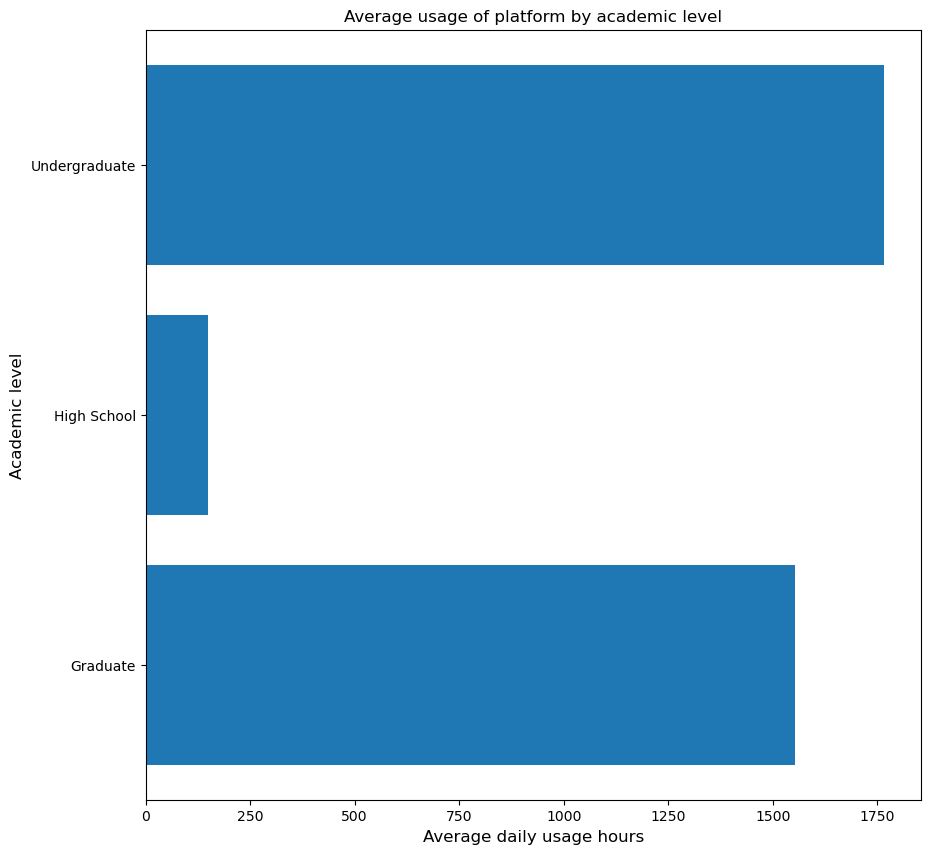

In [16]:
plt.figure(figsize = (10, 10))
plt.barh(daily_use['Academic_Level'], daily_use['Avg_Daily_Usage_Hours'])
plt.xlabel('Average daily usage hours', size = 12)
plt.ylabel('Academic level', size = 12)
plt.legend([], [], frameon = False)
plt.title('Average usage of platform by academic level')
plt.show()

## Insights:
- A lot of students who spend plenty of time on social media are undergraduates.
- followed by: Graduates and to a lesser degree high school.
- The more hours spent on social media, the larger the effect it has on a student's performance.
## Conclusions:
- undergraduate students use social media for two purposes: to get information about the college's activities and subjects, to socialize with their friends.
- Graduates use social media to find jobs.
- High school don't have time to spend on social media due to school's abundance of student activies and subjects.

## Goal 2: Effect of social media on students' mental health.

In [31]:
df

,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
0,1,19,Female,Undergraduate,Bangladesh,5.2,Instagram,Yes,6.5,6,In Relationship,3,8
1,2,22,Male,Graduate,India,2.1,Twitter,No,7.5,8,Single,0,3
2,3,20,Female,Undergraduate,USA,6.0,TikTok,Yes,5.0,5,Complicated,4,9
3,4,18,Male,High School,UK,3.0,YouTube,No,7.0,7,Single,1,4
4,5,21,Male,Graduate,Canada,4.5,Facebook,Yes,6.0,6,In Relationship,2,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...
700,701,20,Female,Undergraduate,Italy,4.7,TikTok,No,7.2,7,In Relationship,2,5
701,702,23,Male,Graduate,Russia,6.8,Instagram,Yes,5.9,4,Single,5,9
702,703,21,Female,Undergraduate,China,5.6,WeChat,Yes,6.7,6,In Relationship,3,7
703,704,24,Male,Graduate,Japan,4.3,Twitter,No,7.5,8,Single,2,4


In [80]:
Mental_health = df[['Avg_Daily_Usage_Hours' ,'Mental_Health_Score', 'Sleep_Hours_Per_Night', 'Addicted_Score']]

In [82]:
Mental_health

,Avg_Daily_Usage_Hours,Mental_Health_Score,Sleep_Hours_Per_Night,Addicted_Score
0,5.2,6,6.5,8
1,2.1,8,7.5,3
2,6.0,5,5.0,9
3,3.0,7,7.0,4
4,4.5,6,6.0,7
...,...,...,...,...
700,4.7,7,7.2,5
701,6.8,4,5.9,9
702,5.6,6,6.7,7
703,4.3,8,7.5,4


In [84]:
Mental_health_sort = Mental_health.sort_values(by = 'Mental_Health_Score', ascending = False)

In [86]:
Mental_health_sort

,Avg_Daily_Usage_Hours,Mental_Health_Score,Sleep_Hours_Per_Night,Addicted_Score
6,1.5,9,8.0,2
311,3.2,8,8.3,4
83,2.7,8,7.2,4
552,3.3,8,8.7,4
97,2.8,8,7.1,4
...,...,...,...,...
607,7.1,4,5.7,9
300,6.9,4,5.2,9
308,7.0,4,5.1,9
675,7.2,4,5.7,9


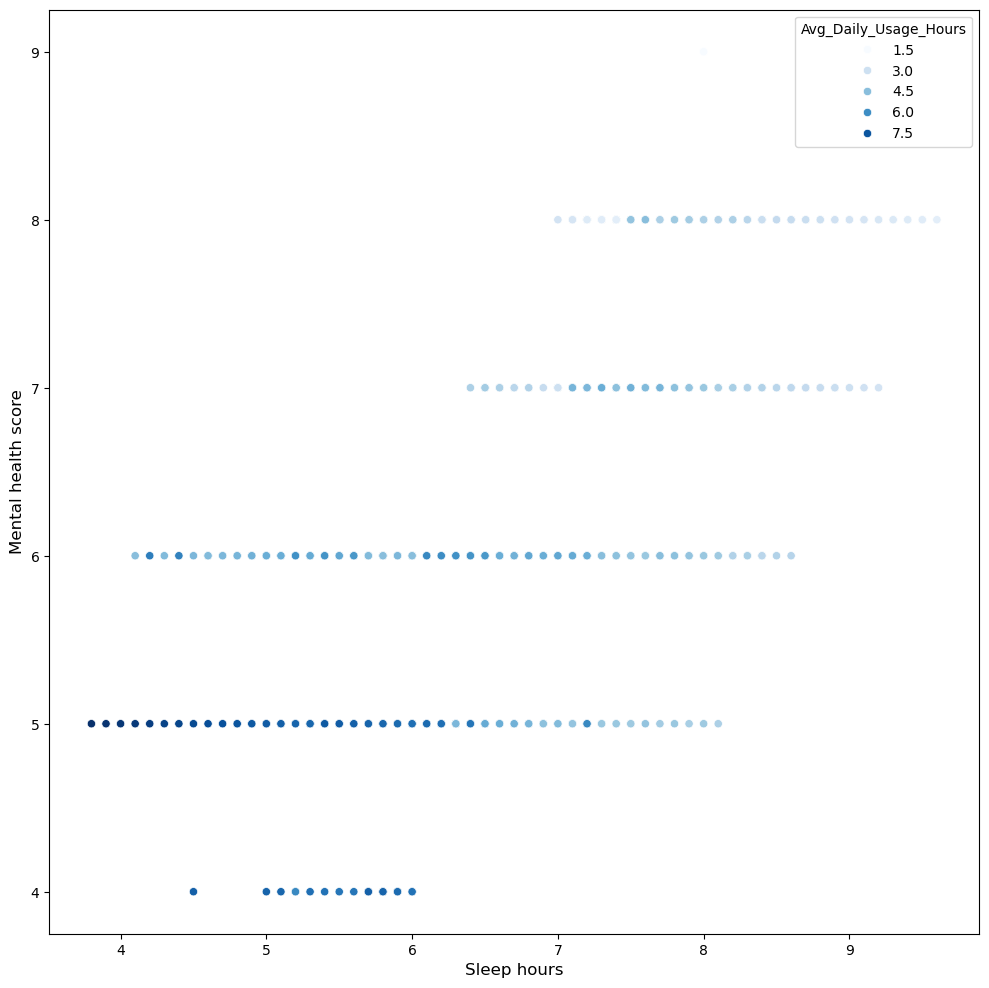

In [90]:
plt.figure(figsize=(12, 12))
sns.scatterplot(data = Mental_health_sort, y = Mental_health_sort['Mental_Health_Score'], x = Mental_health_sort['Sleep_Hours_Per_Night'],
            palette = 'Blues', hue = Mental_health_sort['Avg_Daily_Usage_Hours'])
plt.xlabel('Sleep hours', size = 12)
plt.ylabel('Mental health score', size = 12)
plt.title('Effect of social media on mental health')
plt.show()

## Conclusions:
- Higher times spent on social media lead to low sleep hours and therefore, lower mental stability.
- Students who sleep from 7 to 9 hours tend to spend less time on social media, and therefore higher mental stability.


## Goal 3: What country with the most social media addicted students?

In [96]:
df

,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
0,1,19,Female,Undergraduate,Bangladesh,5.2,Instagram,Yes,6.5,6,In Relationship,3,8
1,2,22,Male,Graduate,India,2.1,Twitter,No,7.5,8,Single,0,3
2,3,20,Female,Undergraduate,USA,6.0,TikTok,Yes,5.0,5,Complicated,4,9
3,4,18,Male,High School,UK,3.0,YouTube,No,7.0,7,Single,1,4
4,5,21,Male,Graduate,Canada,4.5,Facebook,Yes,6.0,6,In Relationship,2,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...
700,701,20,Female,Undergraduate,Italy,4.7,TikTok,No,7.2,7,In Relationship,2,5
701,702,23,Male,Graduate,Russia,6.8,Instagram,Yes,5.9,4,Single,5,9
702,703,21,Female,Undergraduate,China,5.6,WeChat,Yes,6.7,6,In Relationship,3,7
703,704,24,Male,Graduate,Japan,4.3,Twitter,No,7.5,8,Single,2,4


In [112]:
Addiction_sort = df[['Country', 'Addicted_Score']].sort_values(by = 'Addicted_Score', ascending = False)

In [114]:
Addiction_sort

,Country,Addicted_Score
496,USA,9
284,USA,9
573,India,9
326,USA,9
316,USA,9
...,...,...
232,Japan,3
256,Japan,3
240,Japan,3
304,Japan,3


In [122]:
Addiction = Addiction_sort.groupby('Country')['Addicted_Score'].sum().reset_index()

In [124]:
Addiction

,Country,Addicted_Score
0,Afghanistan,5
1,Albania,7
2,Andorra,8
3,Argentina,8
4,Armenia,9
...,...,...
105,Uzbekistan,8
106,Vatican City,7
107,Venezuela,5
108,Vietnam,5


In [126]:
Addiction_sort1 = Addiction.sort_values(by = 'Addicted_Score', ascending = False)

In [128]:
Addiction_sort1

,Country,Addicted_Score
39,India,398
102,USA,344
18,Canada,228
61,Mexico,199
99,Turkey,198
...,...,...
41,Iraq,4
83,San Marino,4
88,South Africa,4
86,Slovakia,3


In [157]:
import plotly.express as px

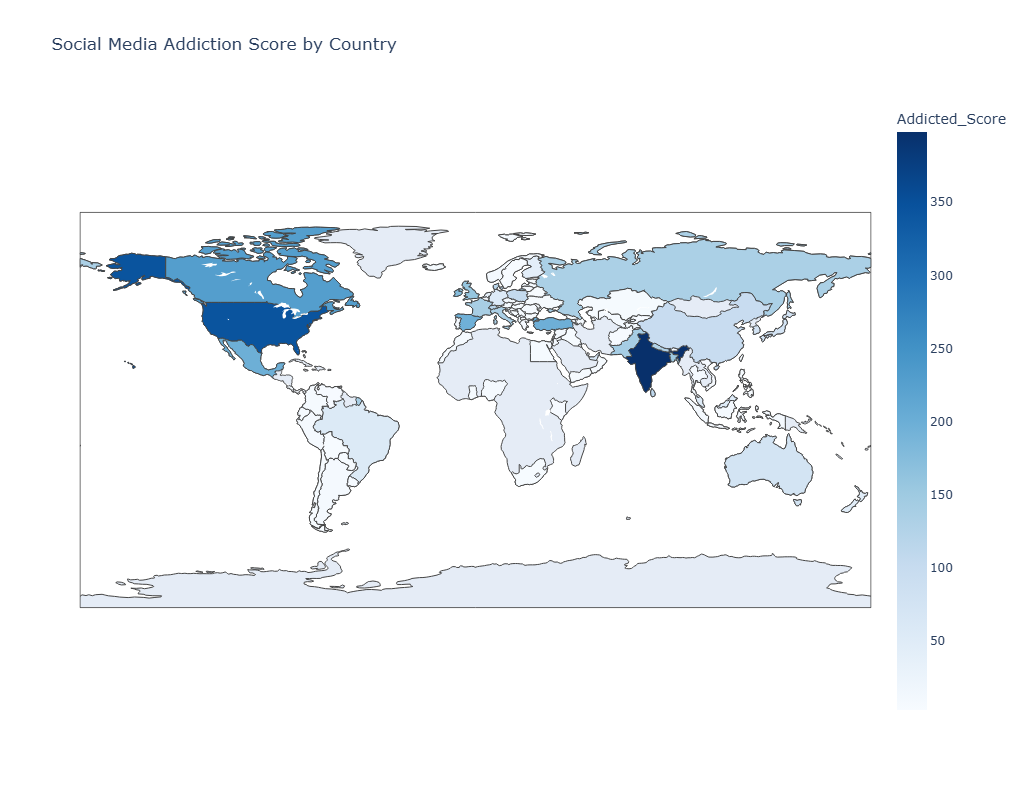

In [169]:
fig = px.choropleth( Addiction_sort1, locations="Country",
    locationmode="country names",
    color="Addicted_Score",
    color_continuous_scale="Blues",
    title="Social Media Addiction Score by Country",
                    width = 1000,
                    height = 800
)
fig.show()



## Insights: 
- India and USA have the highest social media addiction scores, followed by: Canada and Mexico.
- A lot of countries have low social media addiction scores.
## Conclusions:
- India and USA have a lot of social media users, reasons being:
- Work: India and USA focus on data analyzing, computer science and programming fields.
- Social interaction: India has many freelancers working on programming whether they are in India or abroad, In the USA where a lot of people move to states away from their hometowns tend to use social media to stay in contact with their family and friends.

## Goal 4: Compare male students with female students in terms of times of usage of social media platforms

In [173]:
df

,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
0,1,19,Female,Undergraduate,Bangladesh,5.2,Instagram,Yes,6.5,6,In Relationship,3,8
1,2,22,Male,Graduate,India,2.1,Twitter,No,7.5,8,Single,0,3
2,3,20,Female,Undergraduate,USA,6.0,TikTok,Yes,5.0,5,Complicated,4,9
3,4,18,Male,High School,UK,3.0,YouTube,No,7.0,7,Single,1,4
4,5,21,Male,Graduate,Canada,4.5,Facebook,Yes,6.0,6,In Relationship,2,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...
700,701,20,Female,Undergraduate,Italy,4.7,TikTok,No,7.2,7,In Relationship,2,5
701,702,23,Male,Graduate,Russia,6.8,Instagram,Yes,5.9,4,Single,5,9
702,703,21,Female,Undergraduate,China,5.6,WeChat,Yes,6.7,6,In Relationship,3,7
703,704,24,Male,Graduate,Japan,4.3,Twitter,No,7.5,8,Single,2,4


In [191]:
Gender = df.groupby('Gender')['Avg_Daily_Usage_Hours'].sum().reset_index()

In [192]:
Gender

,Gender,Avg_Daily_Usage_Hours
0,Female,1768.9
1,Male,1698.8


## Conclusions:
- Female students spend the most time on social media than male students.
- Females tend to socialize with their friends based on feelings rather than benefits.

## Goal 5: What is the most used social media platform?

In [197]:
Social_Media = df.groupby('Most_Used_Platform')['Student_ID'].count().reset_index()

In [199]:
Social_Media

,Most_Used_Platform,Student_ID
0,Facebook,123
1,Instagram,249
2,KakaoTalk,12
3,LINE,12
4,LinkedIn,21
5,Snapchat,13
6,TikTok,154
7,Twitter,30
8,VKontakte,12
9,WeChat,15


In [201]:
Social_Media_sort = Social_Media.sort_values(by = 'Student_ID', ascending = False)

In [203]:
Social_Media_sort

,Most_Used_Platform,Student_ID
1,Instagram,249
6,TikTok,154
0,Facebook,123
10,WhatsApp,54
7,Twitter,30
4,LinkedIn,21
9,WeChat,15
5,Snapchat,13
2,KakaoTalk,12
3,LINE,12


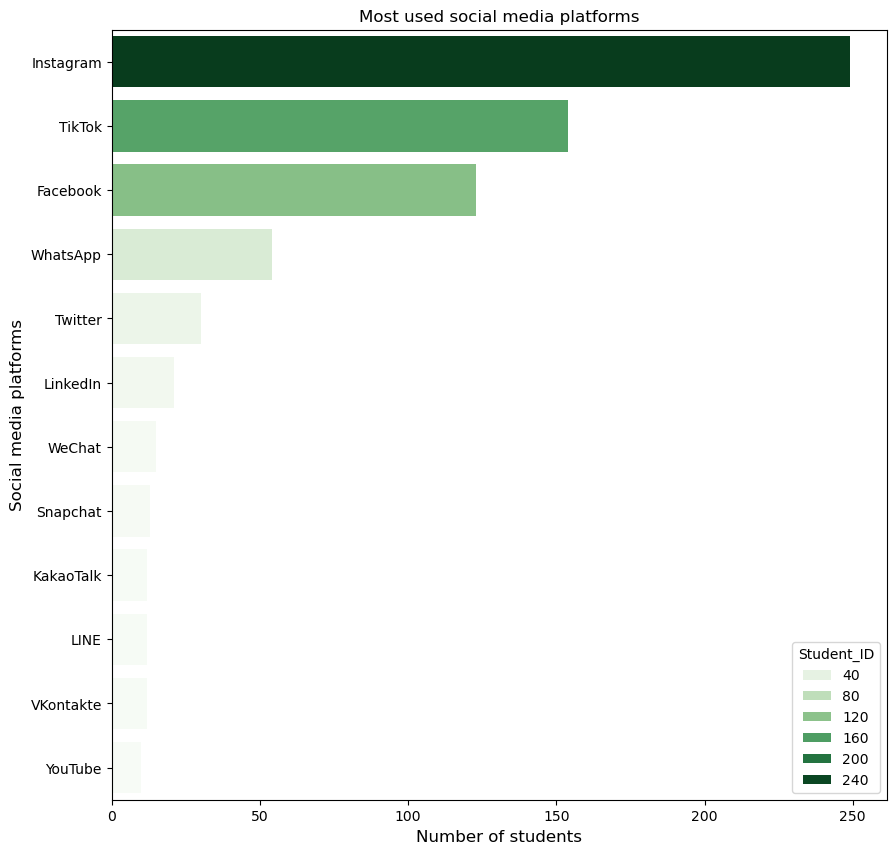

In [210]:
plt.figure(figsize=(10, 10))
sns.barplot(data = Social_Media_sort, y = Social_Media_sort['Most_Used_Platform'], x = Social_Media_sort['Student_ID'], palette = 'Greens', hue = 'Student_ID')
plt.xlabel('Number of students', size = 12)
plt.ylabel('Social media platforms', size = 12)
plt.title('Most used social media platforms')
plt.show()

## Insights:
- Instagram is the most used social media platform.
- Followed by: Tik tok, Facebook and to a lesser degree Whatsapp.
- Twitter (X now), Linedln, WeChat, Snapchat, KakaoTalk, LINE, VKontakte and YouTube are the least used social media platforms.
## Conclusions:
- Social media users tend to browse platfroms that offer visual content (Instagram and TikTok), variable content (Facebook) and message apps (Whatsapp).
- Twitter is a platform that offers limited content: Short posts.
- Linkedln is a plafrom that focuses on job offers and carrer opportunities.
- WeChat, KakaoTalk, LINE and VKontakte are region-specific platforms:
- WeChat is China's Whatsapp.
- KakaoTalk is South Korea's Whtasapp.
- LINE is Japan's Whatsapp.
- VKontakte is Russia's whatspp.

## Goal 6: Social media platforms in terms of countries usage

In [218]:
df

,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
0,1,19,Female,Undergraduate,Bangladesh,5.2,Instagram,Yes,6.5,6,In Relationship,3,8
1,2,22,Male,Graduate,India,2.1,Twitter,No,7.5,8,Single,0,3
2,3,20,Female,Undergraduate,USA,6.0,TikTok,Yes,5.0,5,Complicated,4,9
3,4,18,Male,High School,UK,3.0,YouTube,No,7.0,7,Single,1,4
4,5,21,Male,Graduate,Canada,4.5,Facebook,Yes,6.0,6,In Relationship,2,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...
700,701,20,Female,Undergraduate,Italy,4.7,TikTok,No,7.2,7,In Relationship,2,5
701,702,23,Male,Graduate,Russia,6.8,Instagram,Yes,5.9,4,Single,5,9
702,703,21,Female,Undergraduate,China,5.6,WeChat,Yes,6.7,6,In Relationship,3,7
703,704,24,Male,Graduate,Japan,4.3,Twitter,No,7.5,8,Single,2,4


In [238]:
countries = df[['Country', 'Most_Used_Platform', 'Avg_Daily_Usage_Hours']]

In [240]:
countries

,Country,Most_Used_Platform,Avg_Daily_Usage_Hours
0,Bangladesh,Instagram,5.2
1,India,Twitter,2.1
2,USA,TikTok,6.0
3,UK,YouTube,3.0
4,Canada,Facebook,4.5
...,...,...,...
700,Italy,TikTok,4.7
701,Russia,Instagram,6.8
702,China,WeChat,5.6
703,Japan,Twitter,4.3


In [242]:
countries_use = countries.groupby(['Country', 'Most_Used_Platform'])['Avg_Daily_Usage_Hours'].sum().reset_index()

In [244]:
countries_use

,Country,Most_Used_Platform,Avg_Daily_Usage_Hours
0,Afghanistan,LinkedIn,2.9
1,Albania,TikTok,4.7
2,Andorra,TikTok,5.3
3,Argentina,TikTok,5.5
4,Armenia,Instagram,5.9
...,...,...,...
166,Uzbekistan,TikTok,5.5
167,Vatican City,YouTube,4.4
168,Venezuela,Facebook,3.3
169,Vietnam,Facebook,3.6


In [252]:
countries_use_sort = countries_use.sort_values(by = 'Avg_Daily_Usage_Hours', ascending = False)

In [254]:
countries_use_sort

,Country,Most_Used_Platform,Avg_Daily_Usage_Hours
61,India,WhatsApp,169.4
161,USA,Instagram,133.3
96,Mexico,WhatsApp,116.1
162,USA,TikTok,115.3
45,France,Instagram,85.7
...,...,...,...
134,South Africa,LinkedIn,2.3
88,Malaysia,LinkedIn,2.2
60,India,Twitter,2.1
143,Sweden,LinkedIn,2.0


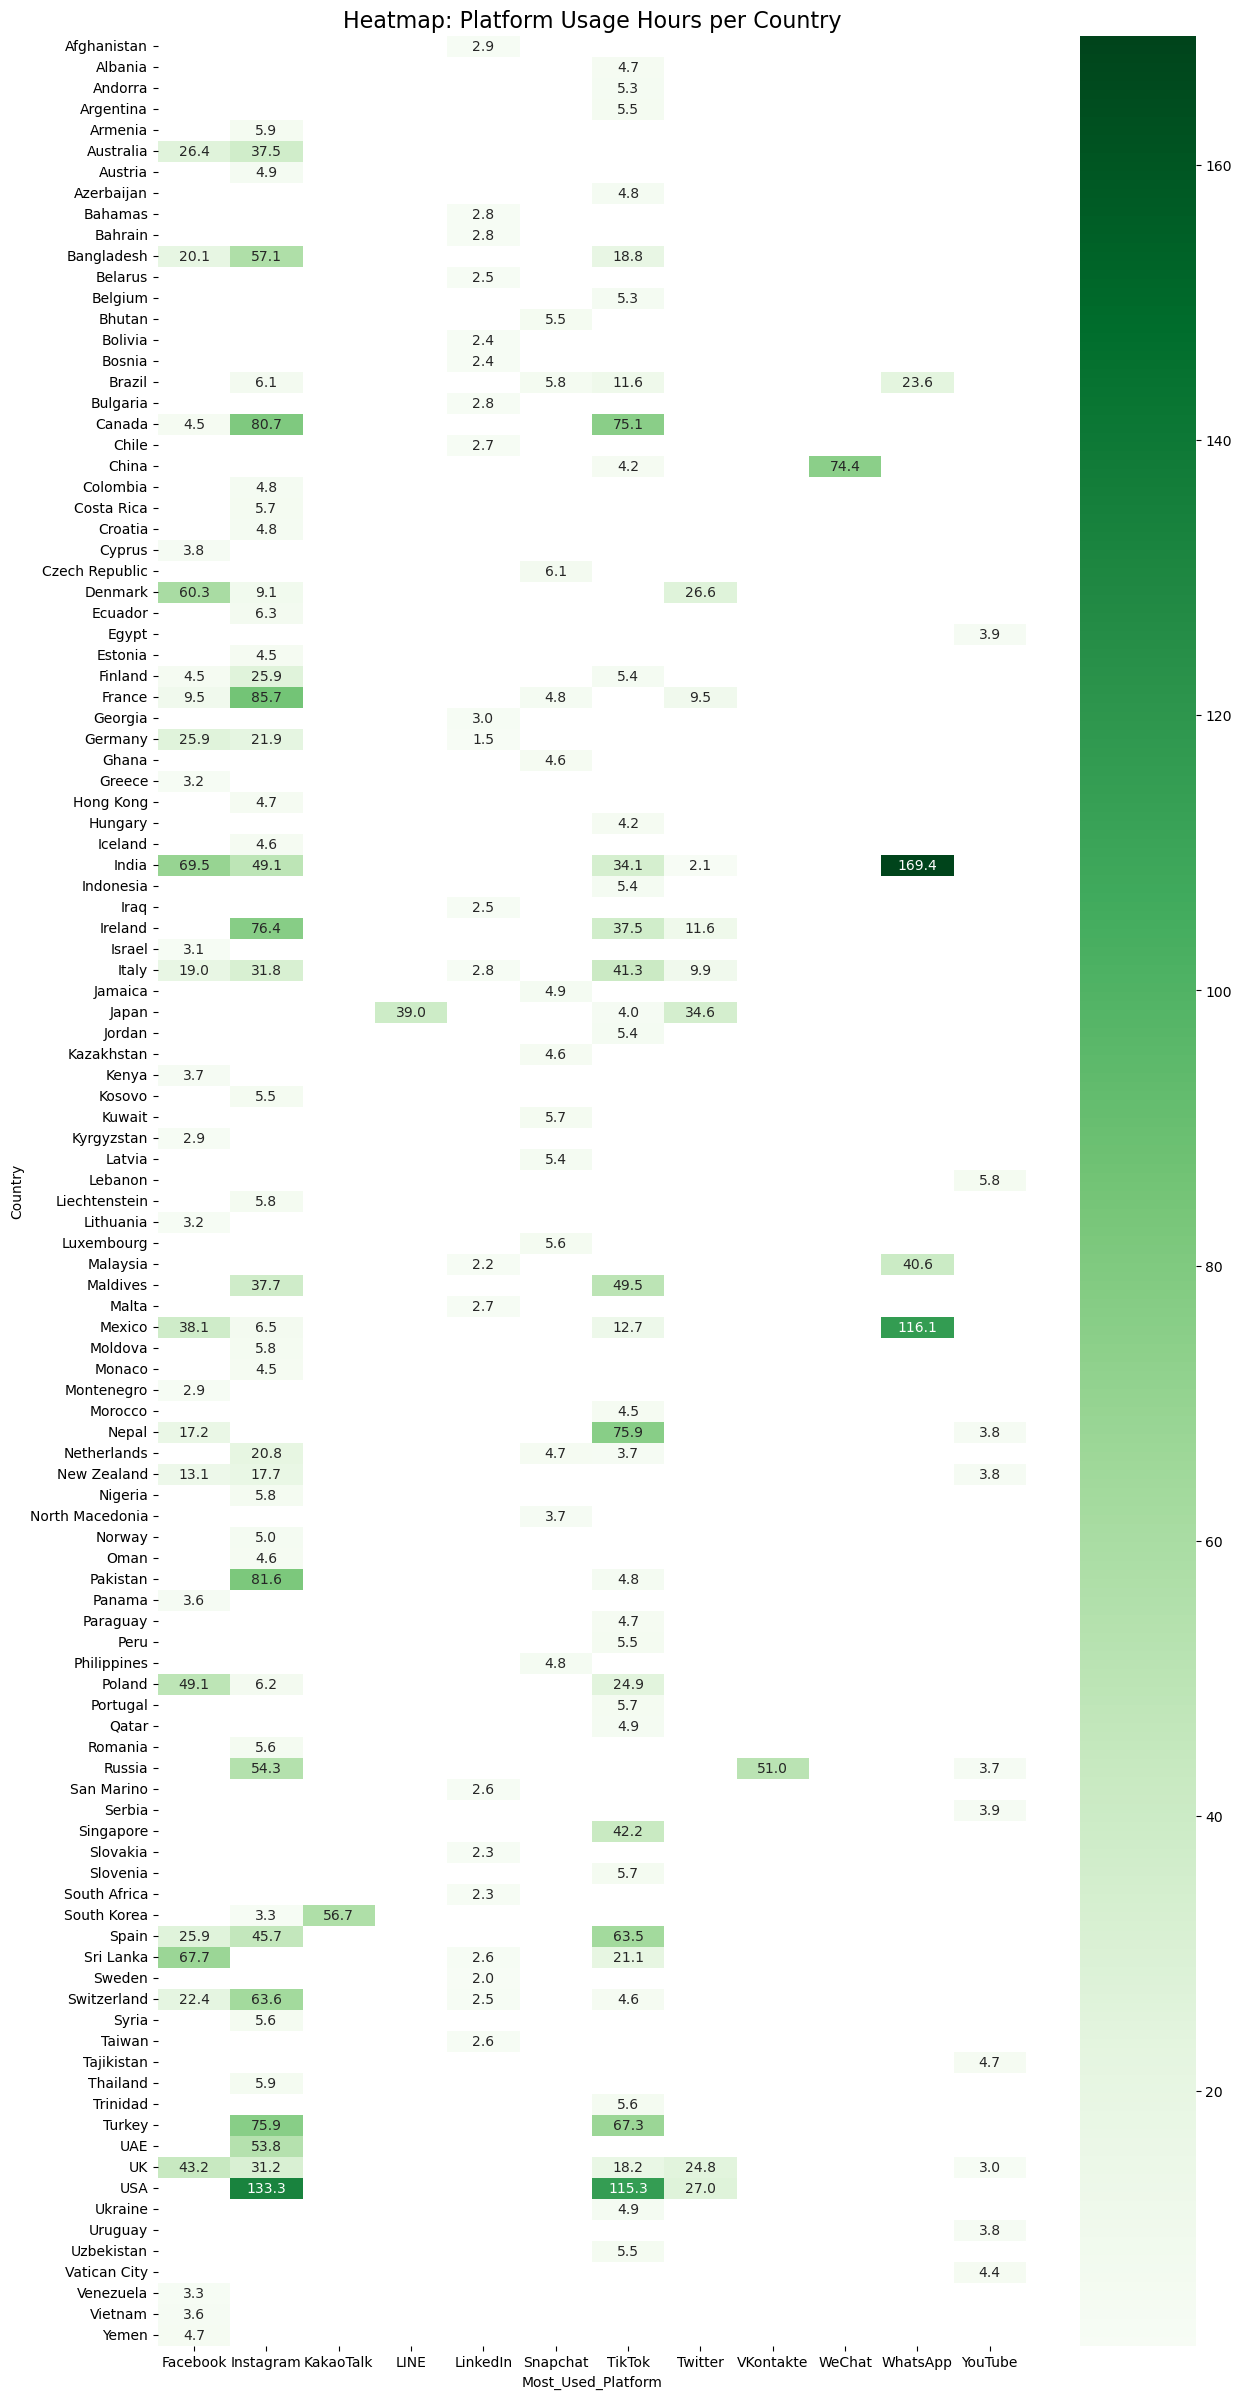

In [275]:
pivot = countries_use_sort.pivot_table(
    index='Country',
    columns='Most_Used_Platform',
    values='Avg_Daily_Usage_Hours',
    aggfunc='sum'
)

plt.figure(figsize=(14, 30))
sns.heatmap(pivot, cmap='Greens', annot=True, fmt='.1f')
plt.title('Heatmap: Platform Usage Hours per Country', fontsize=16)
plt.show()

## Insights:
- India and Mexico show the highest average daily usage hours, particularly on WhatsApp, indicating these students rely heavily on message-based communication.
- USA stands out with high usage on Instagram and TikTok, suggesting stronger engagement with image-based and short-form video platforms.
- Other countries show moderate usage levels, indicating a balanced social media behavior without extreme overuse.
- Different countries prefer different dominant platforms, reflecting cultural, linguistic, and social communication differences.
## Conclusions:
## India:
- The high usage of WhatsApp suggests students use it for academic group discussions, freelance communication, and community-based interactions, which are common in India’s digital culture.
## Mexico:
- Similar to India, WhatsApp is widely used for daily communication and coordination, which explains their high average hours.
## USA: 
- The preference for Instagram and TikTok indicates that students primarily use social media for entertainment, social interaction, content consumption, and maintaining personal networks.
## Overall:
- Students worldwide rely on social media for communication, entertainment, and productivity, but the choice of platform strongly varies by country, influenced by cultural habits and digital infrastructure.